In [1]:
from os import makedirs
import os

# print(os.environ)
from typing import Dict, List, Tuple

import torch
from torch.utils.data import DataLoader
from torch.nn.utils import parameters_to_vector

import argparse
from archs import load_architecture
from utilities import get_loss_and_acc, compute_losses, \
    save_files, save_files_final, get_hessian_eigenvalues, make_base_directory, iterate_dataset
from data import load_dataset, DATASETS, take_first
import dataclasses
import NGD
import tracemalloc
import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "mse"
max_steps = 5000
model_params = NGD.EmpiricalNGD.Params(
    lr = 0.001,
    fisher_batch_size=1000,
    physical_batch_size=1000,
    epsilon= 1e-5,
)
seed = 0

train_dataset, test_dataset = load_dataset(dataset, loss)

directory = f"{make_base_directory(dataset, arch_id, loss)}/seed_{seed}/ngd/{model_params.get_dirname()}"
print(f"Loading from {directory}")

Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/mse/seed_0/ngd/lr_0.001__fisher_bs_1000__phys_bs_1000__epsilon_1e-05


In [3]:
model = load_architecture(arch_id, dataset)
model.load_state_dict(torch.load(f"{directory}/snapshot_final", map_location="cpu"))
model.to("cpu")
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=2048, out_features=10, bias=True)
)

In [4]:
class datapoint:
    def __init__(self, model_probs, emp_FIM_diag, FIM_diag, loglikelihood, mse, class_id):
        self.loglikelihood = loglikelihood
        self.mse = mse
        self.class_id = class_id
        self.emp_FIM_diag_norm = torch.sqrt(torch.sum(torch.stack([torch.sum(f**2) for f in emp_FIM_diag])))
        self.FIM_diag_norm = torch.sqrt(torch.sum(torch.stack([torch.sum(f**2) for f in FIM_diag])))
        self.correct = torch.argmax(model_probs, dim=1) == class_id

def calc_datapoint(X, y, model, activation_fn, params, device = "cuda", num_classes = 10):
    X = X.to(device)
    y = y.to(device)
    class_id = torch.argmax(y, dim=1).item() if y.ndim > 1 else y.item()
    if y.ndim == 1:
        y = torch.nn.functional.one_hot(y, num_classes=num_classes).float().to(device)
        
    model_logits = model(X)

    if activation_fn is not None:
        model_probs = activation_fn(model_logits)
    else:
        model_probs = model_logits
    
    llh = torch.sum(model_probs * y, dim=1)
    true_label_llh = torch.log(llh + params.epsilon)
    mse = torch.mean((model_logits - y) ** 2)
    grads = torch.autograd.grad(true_label_llh, model.parameters(), retain_graph=False)
    
    emp_FIM_diag = [grad**2 for grad in grads]

    FIM_diag = [torch.zeros_like(param) for param in model.parameters()]
            
    for cl in range(num_classes):
        model_logits = model(X)  # fresh forward pass
        if activation_fn:
            model_probs = activation_fn(model_logits)
        else:
            model_probs = model_logits

        likeh = model_probs[0][cl]
        cl_loglikeh = torch.log(likeh + params.epsilon)
        # print(f"Calculating Fisher for class {cl} with likeh {likeh.item()}")
        
        grads = torch.autograd.grad(cl_loglikeh, model.parameters(), retain_graph=False)
        for j, param in enumerate(model.parameters()):
            FIM_diag[j] += likeh * (grads[j] ** 2)


    return datapoint(
        model_probs,
        emp_FIM_diag,
        FIM_diag,
        true_label_llh.to("cpu"),
        mse,
        class_id
    )
    

def calc_fisher_diag_dict(
    dataset,
    params: NGD.EmpiricalNGD.Params,
    device: str = "cpu", 
    activation_fn= torch.nn.Softmax(dim=1),
    ):
    
    result = []

    for i, (X, y) in enumerate(tqdm.tqdm(iterate_dataset(dataset, 1), total=len(dataset), desc="Calculating Fisher Diagonal")):    
        result.append(calc_datapoint(X, y, model, activation_fn, params, device))
        
    return result

In [5]:
datapoints = calc_fisher_diag_dict(
    test_dataset,
    model_params,
    device="cpu",
)

Calculating Fisher Diagonal: 100%|██████████| 10000/10000 [03:01<00:00, 55.23it/s]


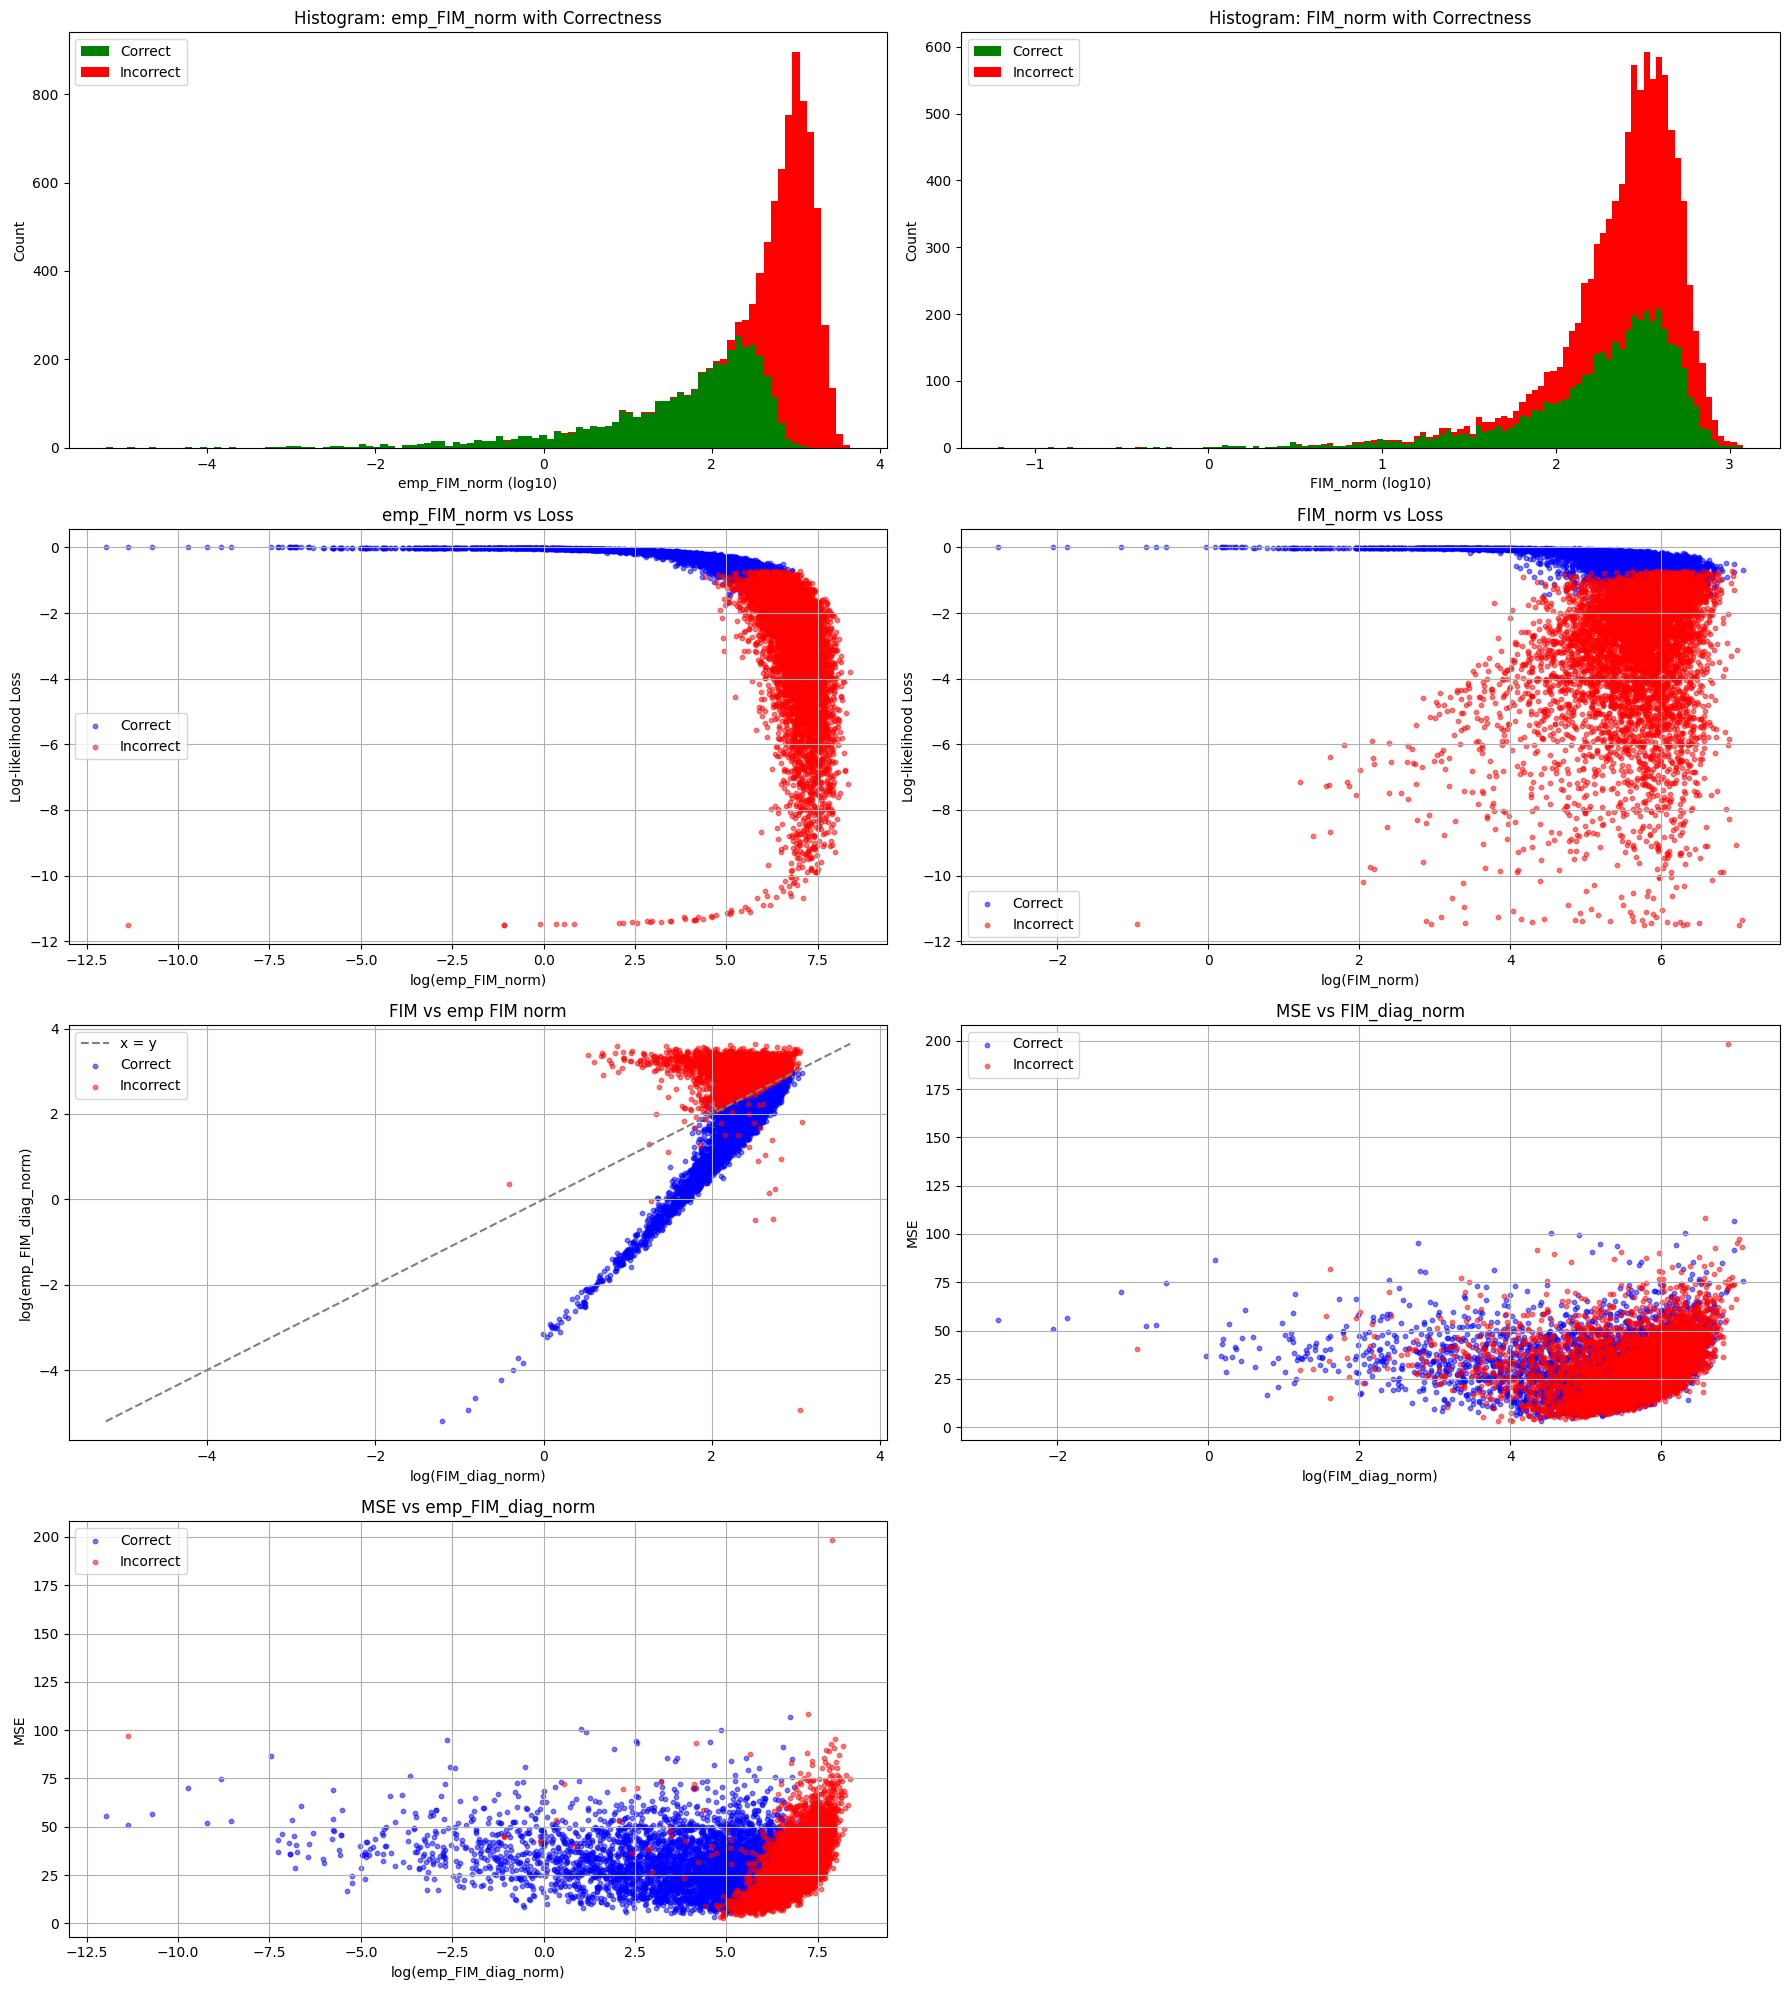

In [13]:
fig, axs = plt.subplots(4, 2, figsize=(18, 20))
axs = axs.flatten()

# Plot 1: Histogram with emp_FIM_diag_norm
fim_norms = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct for dp in datapoints])
bins = np.histogram_bin_edges(fim_norms, bins='auto')
correct_hist, _ = np.histogram(fim_norms[correct_flags], bins=bins)
incorrect_hist, _ = np.histogram(fim_norms[~correct_flags], bins=bins)
bar_widths = np.diff(bins)
x_pos = bins[:-1]
axs[0].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
axs[0].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
axs[0].set_xlabel('emp_FIM_norm (log10)')
axs[0].set_ylabel('Count')
axs[0].set_title('Histogram: emp_FIM_norm with Correctness')
axs[0].legend()

# Plot 2: Histogram with FIM_diag_norm
fim_norms = torch.tensor([np.log10(dp.FIM_diag_norm.item()) for dp in datapoints])
bins = np.histogram_bin_edges(fim_norms, bins='auto')
correct_hist, _ = np.histogram(fim_norms[correct_flags], bins=bins)
incorrect_hist, _ = np.histogram(fim_norms[~correct_flags], bins=bins)
bar_widths = np.diff(bins)
x_pos = bins[:-1]
axs[1].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
axs[1].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
axs[1].set_xlabel('FIM_norm (log10)')
axs[1].set_ylabel('Count')
axs[1].set_title('Histogram: FIM_norm with Correctness')
axs[1].legend()

# Plot 3: emp_FIM_diag_norm vs Log-likelihood Loss
fim_norms = torch.tensor([np.log(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
axs[2].scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[2].scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[2].set_xlabel('log(emp_FIM_norm)')
axs[2].set_ylabel('Log-likelihood Loss')
axs[2].set_title('emp_FIM_norm vs Loss')
axs[2].legend()
axs[2].grid(True)

# Plot 4: FIM_diag_norm vs Log-likelihood Loss
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([dp.loglikelihood.item() for dp in datapoints])
correct_mask = correct_flags.bool()
incorrect_mask = ~correct_mask
axs[3].scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[3].scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[3].set_xlabel('log(FIM_norm)')
axs[3].set_ylabel('Log-likelihood Loss')
axs[3].set_title('FIM_norm vs Loss')
axs[3].legend()
axs[3].grid(True)


# Plot 5: FIM_diag_norm vs emp_FIM_diag_norm
fim_diag_log = torch.tensor([np.log10(dp.FIM_diag_norm.item()) for dp in datapoints])
emp_fim_log = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
min_val = min(fim_diag_log.min(), emp_fim_log.min()).item()
max_val = max(fim_diag_log.max(), emp_fim_log.max()).item()
axs[4].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='x = y')
axs[4].scatter(fim_diag_log[correct_mask], emp_fim_log[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[4].scatter(fim_diag_log[incorrect_mask], emp_fim_log[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[4].set_xlabel('log(FIM_diag_norm)')
axs[4].set_ylabel('log(emp_FIM_diag_norm)')
axs[4].set_title('FIM vs emp FIM norm')
axs[4].legend()
axs[4].grid(True)

# Plot 6: MSE vs FIM_diag_norm
mses = torch.tensor([dp.mse.item() for dp in datapoints])
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
axs[5].scatter(fim_norms[correct_mask], mses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[5].scatter(fim_norms[incorrect_mask], mses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[5].set_xlabel('log(FIM_diag_norm)')
axs[5].set_ylabel('MSE')
axs[5].set_title('MSE vs FIM_diag_norm')
axs[5].legend()
axs[5].grid(True)

# Plot 7: MSE vs emp_FIM_diag_norm
fim_norms_emp = torch.tensor([np.log(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
axs[6].scatter(fim_norms_emp[correct_mask], mses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[6].scatter(fim_norms_emp[incorrect_mask], mses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[6].set_xlabel('log(emp_FIM_diag_norm)')
axs[6].set_ylabel('MSE')
axs[6].set_title('MSE vs emp_FIM_diag_norm')
axs[6].legend()
axs[6].grid(True)

# Plot 8: empty or any additional metric (optional)
axs[7].axis('off')  # or reuse for another diagnostic plot

plt.tight_layout()
plt.show()
